In [70]:
#imports
import sys
import numpy as np
import pandas as pd
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [71]:
#do what we did above
all_df = ["comments1.csv","comments2.csv", "comments3.csv", "comments4.csv", "comments5.csv"]
dfs = []  # list to hold each dataframe
for fname in all_df:
    df = pd.read_csv("dataset/" + fname)
    
    trend = df[["textOriginal", "likeCount", "publishedAt"]]
    trend = trend.dropna(subset=["textOriginal"])
    trend['publishedAt'] = pd.to_datetime(trend['publishedAt'], format='%Y-%m-%d %H:%M:%S%z', utc=True)
    first_date = trend["publishedAt"].min()
    trend["days_since_first"] = (trend["publishedAt"] - first_date).dt.days.astype(float)

    filtered_likes_df = trend[trend["likeCount"] > 0]
    average_like_count = filtered_likes_df["likeCount"].mean()
    successful_comments = trend[trend["likeCount"] >= average_like_count]
    dfs.append(successful_comments)

#vertically concat
total_df = pd.concat(dfs, ignore_index=True)

def log1p_mapper(like : float) -> float:
    values = np.log1p(like)
    return values

total_df["likeCountLn"] = total_df['likeCount'].apply(log1p_mapper)



In [72]:
sia = SentimentIntensityAnalyzer()
def extract_enhanced_features(text):
    """Extract comprehensive features for comment quality assessment"""
    if pd.isna(text) or not isinstance(text, str):
        return {
            'comment_length': 0,
            'word_count': 0,
            'has_emoji': 0,
            'has_mention': 0,
            'has_hashtag': 0,
            'has_url': 0,
            'exclamation_count': 0,
            'question_count': 0,
            'caps_ratio': 0,
            'sentiment_compound': 0,
            'sentiment_positive': 0,
            'sentiment_negative': 0,
            'sentiment_neutral': 0
        }
    
    # Basic text features
    comment_length = len(text)
    word_count = len(text.split())
    
    # Pattern detection
    has_mention = 1 if '@' in text else 0
    has_hashtag = 1 if '#' in text else 0
    has_url = 1 if bool(re.search(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text)) else 0
    
    # Punctuation analysis
    exclamation_count = text.count('!')
    question_count = text.count('?')
    
    # Caps analysis
    if len(text) > 0:
        caps_ratio = sum(1 for c in text if c.isupper()) / len(text)
    else:
        caps_ratio = 0
    
    # Sentiment analysis
    sentiment_scores = sia.polarity_scores(text)
    
    return {
        'comment_length': comment_length,
        'word_count': word_count,
        'has_mention': has_mention,
        'has_hashtag': has_hashtag,
        'has_url': has_url,
        'exclamation_count': exclamation_count,
        'question_count': question_count,
        'caps_ratio': caps_ratio,
        'sentiment_compound': sentiment_scores['compound'],
        'sentiment_positive': sentiment_scores['pos'],
        'sentiment_negative': sentiment_scores['neg'],
        'sentiment_neutral': sentiment_scores['neu']
    }

In [73]:
print("Extracting enhanced features...")
feature_list = []
for text in total_df['textOriginal']:
    features = extract_enhanced_features(text)
    feature_list.append(features)

# Add features to dataframe
feature_df = pd.DataFrame(feature_list)
for col in feature_df.columns:
    total_df[col] = feature_df[col]

Extracting enhanced features...


In [74]:
def detect_spam_indicators(text):
    """Detect spam indicators in comments"""
    if pd.isna(text) or not isinstance(text, str):
        return 0.0
    
    text_lower = text.lower()
    spam_indicators = 0
    
    # Common spam patterns
    spam_patterns = [
        r'\b(first|second|third|1st|2nd|3rd)\b',  # "First!" comments
        r'(check out|visit|click|link in bio)',    # Promotional
        r'(subscribe|follow|like if)',             # Call to action spam
        r'(\w)\1{3,}',                            # Repeated characters (aaaa, lol)
        r'^.{1,5}$'                               # Very short comments
    ]
    
    for pattern in spam_patterns:
        if re.search(pattern, text_lower):
            spam_indicators += 1
    
    # Normalize to 0-1 scale
    spam_score = min(spam_indicators / 3.0, 1.0)  # Cap at 1.0
    return spam_score

# Add spam detection
print("Adding spam detection...")
total_df['spam_probability'] = total_df['textOriginal'].apply(detect_spam_indicators)

Adding spam detection...


In [75]:
def classify_beauty_category(text):
    """Classify comments into beauty categories"""
    if pd.isna(text) or not isinstance(text, str):
        return 'other'
    
    text_lower = text.lower()
    
    # Beauty category keywords
    skincare_keywords = ['skincare', 'skin', 'face', 'moisturizer', 'serum', 'cleanser', 'acne', 'wrinkle', 'anti-aging']
    makeup_keywords = ['makeup', 'foundation', 'lipstick', 'mascara', 'eyeshadow', 'blush', 'concealer', 'contour']
    haircare_keywords = ['hair', 'shampoo', 'conditioner', 'styling', 'curly', 'straight', 'color', 'dye']
    fragrance_keywords = ['perfume', 'fragrance', 'scent', 'cologne', 'smell', 'aroma']
    
    # Count matches for each category
    skincare_score = sum(1 for word in skincare_keywords if word in text_lower)
    makeup_score = sum(1 for word in makeup_keywords if word in text_lower)
    haircare_score = sum(1 for word in haircare_keywords if word in text_lower)
    fragrance_score = sum(1 for word in fragrance_keywords if word in text_lower)
    
    # Determine dominant category
    scores = {
        'skincare': skincare_score,
        'makeup': makeup_score,
        'haircare': haircare_score,
        'fragrance': fragrance_score
    }
    
    max_score = max(scores.values())
    if max_score == 0:
        return 'other'
    
    return max(scores, key=scores.get)

# Add category classification
print("Adding beauty category classification...")
total_df['beauty_category'] = total_df['textOriginal'].apply(classify_beauty_category)


Adding beauty category classification...


In [76]:
def calculate_quality_score(row):

    relevance_score = 0.8 if row['beauty_category'] != 'other' else 0.2

    max_likes = total_df['likeCount'].max()
    engagement_score = min(row['likeCount'] / (max_likes * 0.1), 1.0)  # Cap at reasonable level

    sentiment_score = max(0, row['sentiment_compound'] + 1) / 2  # Convert from [-1,1] to [0,1]
    
    # Length quality (moderate length is better)
    if row['word_count'] < 3:
        length_score = 0.3  # Too short
    elif row['word_count'] > 50:
        length_score = 0.7  # Too long
    else:
        length_score = 1.0  # Good length
    
    # Interaction quality (comments with mentions/hashtags show engagement)
    interaction_score = 0.5  # Base score
    if row['has_mention']:
        interaction_score += 0.2
    if row['has_hashtag']:
        interaction_score += 0.2
    if row['has_url']:
        interaction_score -= 0.1  # URLs might be promotional
    interaction_score = min(interaction_score, 1.0)  # Cap at 1.0

    spam_penalty = 1 - row['spam_probability']
    
    # Expressiveness (appropriate use of punctuation shows engagement)
    if 1 <= row['exclamation_count'] <= 3:
        express_score = 1.0
    elif row['question_count'] >= 1:
        express_score = 0.8  # Questions show engagement
    elif row['exclamation_count'] > 3:
        express_score = 0.5  # Too many exclamations might be spam
    else:
        express_score = 0.6  # Neutral
    
    # Weighted combination
    quality_score = (
        relevance_score * 0.25 +
        engagement_score * 0.20 +      
        sentiment_score * 0.20 +
        length_score * 0.15 +
        interaction_score * 0.10 +
        express_score * 0.1
    ) * spam_penalty  # Apply caps penalty
    
    return round(quality_score, 3)

#add a quality score for every comment through calculations
total_df['quality_score'] = total_df.apply(calculate_quality_score, axis=1)

In [77]:
def assign_quality_tier(score):
    if score >= 0.7:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

total_df['quality_tier'] = total_df['quality_score'].apply(assign_quality_tier)

In [78]:
#machine learning imports
from lightgbm import LGBMRegressor   
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

In [79]:
# features and label

enhanced_features = [
    'days_since_first', 'comment_length', 'word_count', 'has_mention', 
    'has_hashtag', 'exclamation_count', 'question_count', 'caps_ratio',
    'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 
    'spam_probability','likeCountLn'
]

X = total_df[["textOriginal"] + enhanced_features] #feature
y = total_df["quality_score"]    #label

# text + numeric preprocessing
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1,2), min_df=5) #https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
#only transform the features for training, they become a matrix
pre = ColumnTransformer([
    ("txt", tfidf, "textOriginal"),
    ("num", "passthrough", enhanced_features),
])

#model receives feature matrix and y_train to create model
model = LGBMRegressor(
    n_estimators=400, #num of trees
    learning_rate=0.05, #slower learning rate per tree but more stable
    subsample=0.85, #each tree takes 85 percent of the training dataset to avoid overfitting
    colsample_bytree=0.85,
    reg_lambda=0.5,
    n_jobs=-1
)

pipe = Pipeline([
    ("pre", pre),
    ("model", model),
])

# train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)

# evaluate
y_pred = pipe.predict(X_val)
print("RMSE:", root_mean_squared_error(y_val, y_pred))
print("R^2:", r2_score(y_val, y_pred))

# add predictions back
total_df["pred"] = pipe.predict(X)
total_df["pred_quality_score"] = pipe.predict(X)
total_df["pred_quality_tier"] = total_df["pred_quality_score"].apply(assign_quality_tier)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.252257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 149300
[LightGBM] [Info] Number of data points in the train set: 34366, number of used features: 3980
[LightGBM] [Info] Start training from score 0.483624


c:\Users\daymo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 0.01846735827557965
R^2: 0.9664048537703044


c:\Users\daymo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\daymo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [80]:
total_df.head(20) 

,textOriginal,likeCount,publishedAt,days_since_first,likeCountLn,comment_length,word_count,has_mention,has_hashtag,has_url,...,sentiment_positive,sentiment_negative,sentiment_neutral,spam_probability,beauty_category,quality_score,quality_tier,pred,pred_quality_score,pred_quality_tier
0,How do you achieve that slick back? 🧐,684,2025-01-28 09:03:05+00:00,1850.0,6.529419,37,8,0,0,0,...,0.000,0.000,1.000,0.000000,other,0.433,Medium,0.437819,0.437819,Medium
1,"“If it rains, I’m ruined” was so REALL😭😮😢",88,2024-07-13 05:19:05+00:00,1651.0,4.488636,41,8,0,0,0,...,0.000,0.000,1.000,0.000000,other,0.410,Medium,0.411692,0.411692,Medium
2,Can we please go back to Classic beauty?,75,2024-06-11 04:17:52+00:00,1619.0,4.330733,40,8,0,0,0,...,0.504,0.000,0.496,0.000000,other,0.503,Medium,0.501830,0.501830,Medium
3,POPULAR..YOURE GONNA BE POPULARR!,701,2024-11-25 15:03:24+00:00,1787.0,6.553933,33,4,0,0,0,...,0.000,0.000,1.000,0.000000,other,0.453,Medium,0.453103,0.453103,Medium
4,"Bro my skincare routine is soap, water and a t...",808,2023-04-29 16:40:35+00:00,1211.0,6.695799,120,24,0,0,0,...,0.311,0.081,0.608,0.333333,skincare,0.428,Medium,0.385746,0.385746,Low
5,oh my god slayed that McDonald's speedrun 😍😫 Q...,105,2023-07-12 06:09:08+00:00,1284.0,4.663439,54,9,0,0,0,...,0.208,0.000,0.792,0.333333,other,0.292,Low,0.295527,0.295527,Low
6,me *wishing I had mat skin* randomly getting t...,52,2022-12-15 08:26:18+00:00,1075.0,3.970292,74,14,0,0,0,...,0.000,0.000,1.000,0.000000,skincare,0.560,Medium,0.557277,0.557277,Medium
7,It’s not that makeup can’t cover it. It’s that...,3367,2023-03-06 20:32:21+00:00,1157.0,8.122074,117,22,0,0,0,...,0.099,0.000,0.901,0.000000,skincare,0.607,Medium,0.606071,0.606071,Medium
8,The nurse in me watching the right side to see...,692,2021-07-06 18:57:17+00:00,549.0,6.541030,112,22,0,0,0,...,0.000,0.000,1.000,0.000000,makeup,0.563,Medium,0.557251,0.557251,Medium
9,Ryujin really said: “am i a joke to you 🤨?”,790,2021-04-24 23:33:41+00:00,476.0,6.673298,43,10,0,0,0,...,0.260,0.000,0.740,0.000000,other,0.469,Medium,0.470588,0.470588,Medium


In [81]:
feature_names = pipe.named_steps['pre'].get_feature_names_out()
importances = pipe.named_steps['model'] .feature_importances_

feature_importance = (pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False))

print("\nTop 20 Most Important Features for Quality Prediction:")
print(feature_importance.head(20))


Top 20 Most Important Features for Quality Prediction:
                      feature  importance
4008  num__sentiment_compound         604
4012         num__likeCountLn         434
4002          num__word_count         386
4001      num__comment_length         319
1306                txt__hair         290
2066              txt__makeup         277
4011    num__spam_probability         256
2908                txt__skin         254
1013                txt__face         220
4005   num__exclamation_count         217
4009  num__sentiment_positive         200
1144          txt__foundation         146
4010  num__sentiment_negative         144
1336           txt__hairstyle         139
1920            txt__lipstick         136
4007          num__caps_ratio         134
4000    num__days_since_first         132
665                txt__color         125
2918            txt__skincare         112
472                txt__blush         110


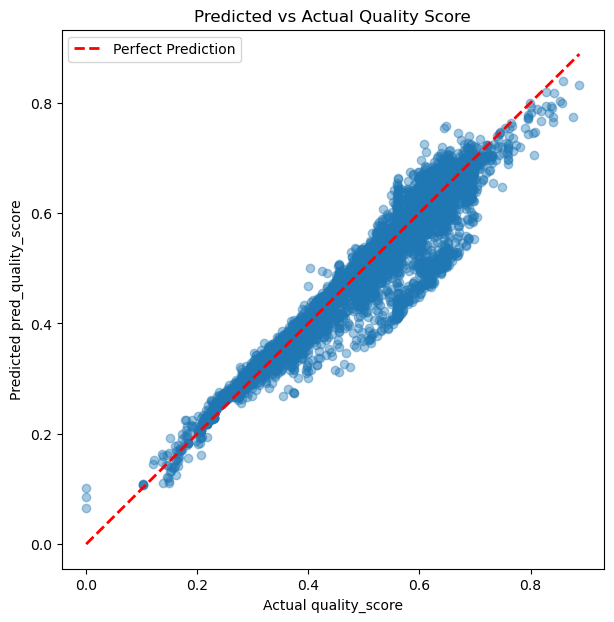

In [82]:

plt.figure(figsize=(7,7))
plt.scatter(total_df["quality_score"], total_df["pred_quality_score"], alpha=0.4)
plt.plot(
    [total_df["quality_score"].min(), total_df["quality_score"].max()],
    [total_df["quality_score"].min(), total_df["quality_score"].max()],
    'r--', lw=2, label="Perfect Prediction"
)
plt.xlabel("Actual quality_score")
plt.ylabel("Predicted pred_quality_score")
plt.title("Predicted vs Actual Quality Score")
plt.legend()
plt.show()